In [1]:
import aqua

from aqua.batchAQUA_general import batchAQUA
from aqua.utils import *
from aqua.stimulus import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import convolve, windows
from tqdm import tqdm
import pickle
import seaborn as sns
sns.set_theme()

from CPA_with_AQUA import *

In [2]:
outfile = "CPA_test_data.pickle"

with open(outfile, 'rb') as file:
    data = pickle.load(file)

print(data.head())
print(data['variance'].unique())


  ISI_TS variance step_height   autapse f FLUSS window       CAC change point
0  False      0.0         0.0         0.0          300  0.588818        150.0
1   True      0.0         0.0         0.0          300  0.979103       1767.6
2  False      0.0         0.0       100.0          300  0.469459        743.1
3   True      0.0         0.0       100.0          300  0.971691        150.0
4  False      0.0         0.0  117.857143          300  0.680763       1144.4
[np.float64(0.0) np.float64(12.5) np.float64(25.0) np.float64(37.5)
 np.float64(50.0)]


Text(0, 0.5, 'CAC on ISI time series')

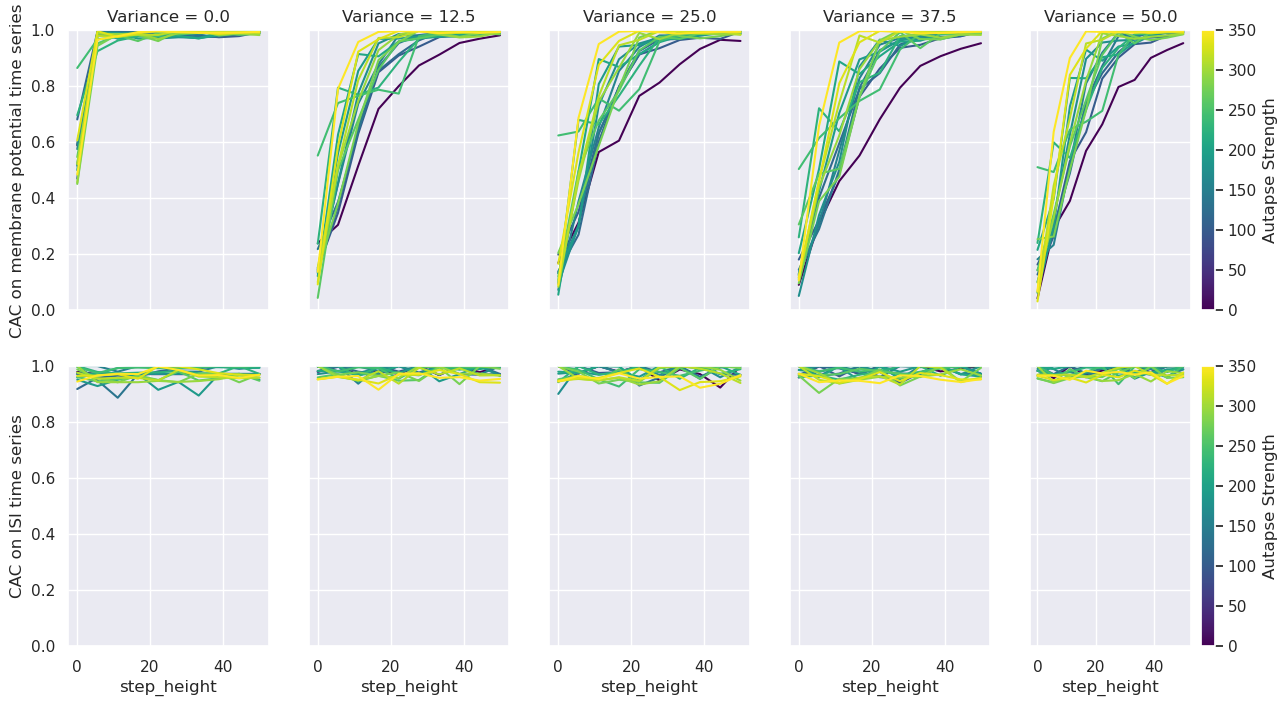

In [3]:
variances = data['variance'].unique()
fig, ax = plt.subplots(2, 5, figsize = (15, 8), sharey = 'row', sharex = 'col')

for n, v in enumerate(variances):
    df = data[(data['variance'] == v)]

    sub_df1 = df[df['ISI_TS'] == False]
    sub_df2 = df[df['ISI_TS'] == True]

    if n == len(variances)-1:
        add_colorbar = True
    else:
        add_colorbar = False

    fig, ax[0, n] = psychometric_curve(sub_df1, x = "step_height", y = "CAC", hue = "autapse f", fig = fig, ax = ax[0, n], add_colorbar = add_colorbar)
    fig, ax[1, n] = psychometric_curve(sub_df2, x = "step_height", y = "CAC", hue = "autapse f", fig = fig, ax = ax[1, n], add_colorbar = add_colorbar)
    
    ax[0, n].set_ylim((0, 1))
    ax[1, n].set_ylim((0, 1))

    ax[0, n].set_title(f"Variance = {v}")

ax[0, 0].set_ylabel("CAC on membrane potential time series")
ax[1, 0].set_ylabel("CAC on ISI time series")

Text(0, 0.5, 'CAC on ISI time series')

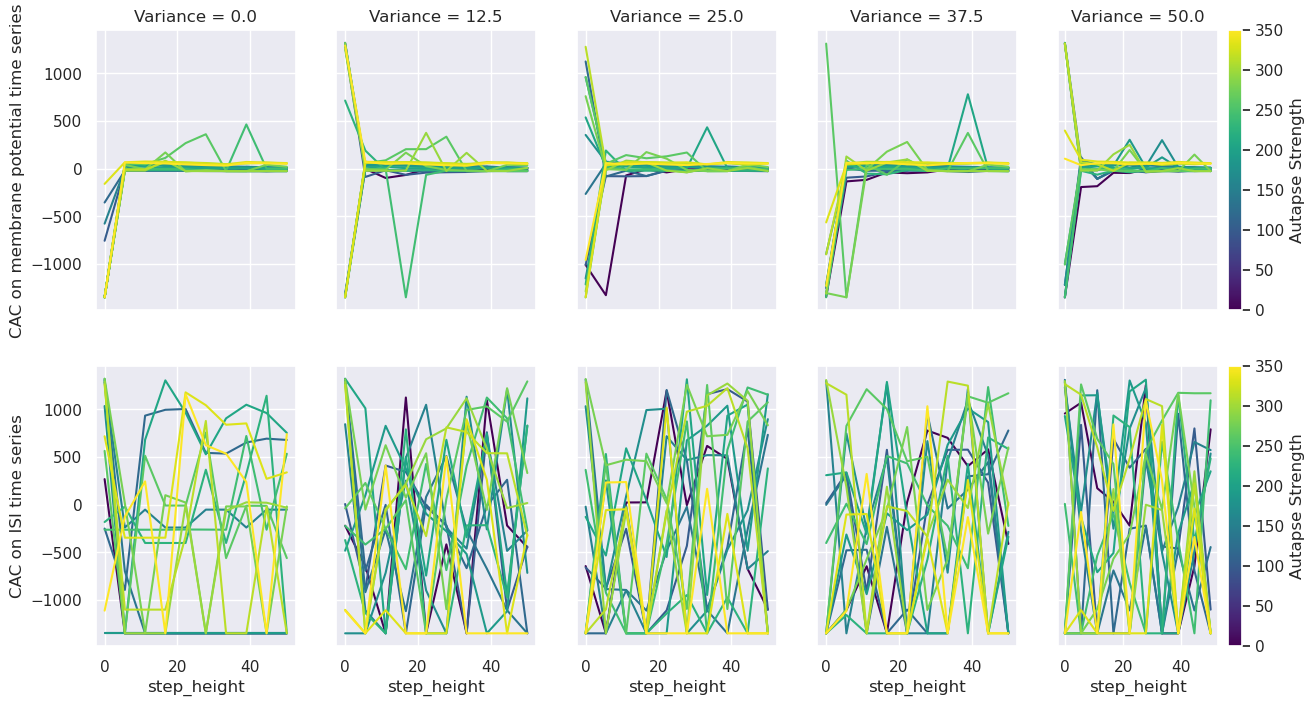

In [4]:
''' TO SUMMARISE CHANGE POINT... '''


variances = data['variance'].unique()
fig, ax = plt.subplots(2, 5, figsize = (15, 8), sharey = 'row', sharex = 'col')

data['delta_CP'] = data['change point'] - 1500 # ms

for n, v in enumerate(variances):
    df = data[(data['variance'] == v)]

    sub_df1 = df[df['ISI_TS'] == False]
    sub_df2 = df[df['ISI_TS'] == True]

    if n == len(variances)-1:
        add_colorbar = True
    else:
        add_colorbar = False

    fig, ax[0, n] = psychometric_curve(sub_df1, x = "step_height", y = "delta_CP", hue = "autapse f", fig = fig, ax = ax[0, n], add_colorbar = add_colorbar)
    fig, ax[1, n] = psychometric_curve(sub_df2, x = "step_height", y = "delta_CP", hue = "autapse f", fig = fig, ax = ax[1, n], add_colorbar = add_colorbar)
    
    ax[0, n].set_title(f"Variance = {v}")

ax[0, 0].set_ylabel("CAC on membrane potential time series")
ax[1, 0].set_ylabel("CAC on ISI time series")